# Decision Tree Worksheet

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [19]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names=names)

invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)
data.head()

X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

/tmp/ipykernel_1564/301033383.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [47]:
decision_tree_highdepth_lowsample = DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth=500, min_samples_leaf=2)

decision_tree_highdepth_lowsample.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=500, min_samples_leaf=2)

Print accuracy of training and validation data.

In [49]:
# Printing accuracy of testing & training data
y_train_pred_highdepth_lowsample=decision_tree_highdepth_lowsample.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred_highdepth_lowsample)*100)
y_val_pred_highdepth_lowsample=decision_tree_highdepth_lowsample.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred_highdepth_lowsample)*100)

Training Accuracy is  96.8
Validation Accuracy is  80.95238095238095


Make a model with a low max-depth and higher minimum sample leafs.

In [58]:
decision_tree_lowdepth_highsample = DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth=4, min_samples_leaf=500)

decision_tree_lowdepth_highsample.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=500)

Print accuracy of training and validation data.

In [59]:
# Printing accuracy of testing & training data
y_train_pred_lowdepth_highsample=decision_tree_lowdepth_highsample.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred_lowdepth_highsample=decision_tree_lowdepth_highsample.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred_lowdepth_highsample)*100)

Training Accuracy is  67.2
Validation Accuracy is  63.49206349206349


In [53]:
decision_tree = DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth=500, min_samples_leaf=500)

decision_tree.fit(X_train, y_train)

# Printing accuracy of testing & training data
y_train_pred=decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  67.2
Validation Accuracy is  63.49206349206349


Explain the accuracy results below.

(A decision tree with a higher max depth tends to overfit much more than a decision tree with a lower max depth, explaining the large difference between training accuracy and validation accuracy in the first example. This is the same case with the min_samples_leaf.)

## Metrics

Plot the ROC curve and print the AUC of the second model.

(63,)
(63,)


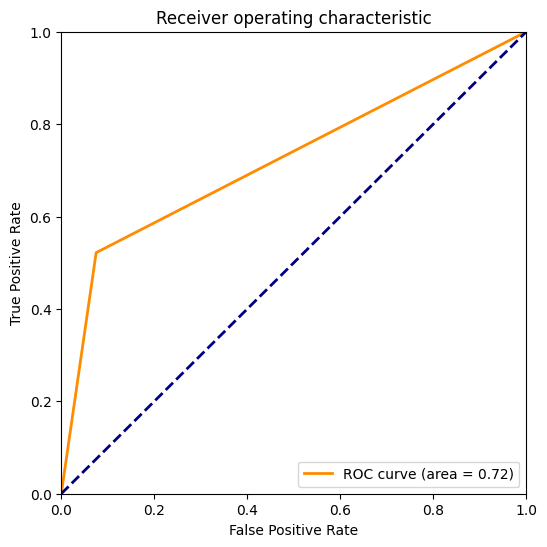

0.7233695652173914


In [32]:
print(y_val.shape)
print(y_val_pred_lowdepth_highsample.shape)
# Calculate the FPR and TPR at varying thresholds (assume label 1 is the "postive" class)
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_pred_lowdepth_highsample)

# Calculate the area under the ROC curve
roc_auc = metrics.auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(6,6))
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

print(roc_auc)

Use graphviz to visualize your 2nd tree.

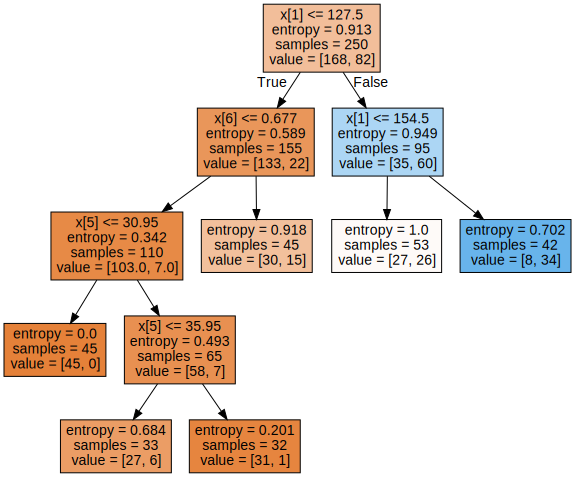

In [33]:
dot_data = tree.export_graphviz(decision_tree_lowdepth_highsample, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

(A certain feature selected by the feature index n)

Question 2: What is the root feature? Does it make sense as the root feature?

(Plasma Glucose Concentration. It does make sense, glucose is one of the major determining factors in diabetes)

In [34]:
data.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

(The Training accuracy would likely be very high due to the large max_depth. However, this could lead to overfitting, and the low min_samples_leaf prevents more data from reaching each leaf, lowering validation accuracy)

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [37]:
decision_tree_q3 = DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth=500, min_samples_leaf=1)

decision_tree_q3.fit(X_train, y_train)

# Printing accuracy of testing & training data
y_train_pred_q3=decision_tree_q3.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred_q3)*100)
y_val_pred_q3=decision_tree_q3.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred_q3)*100)

Training Accuracy is  100.0
Validation Accuracy is  82.53968253968253


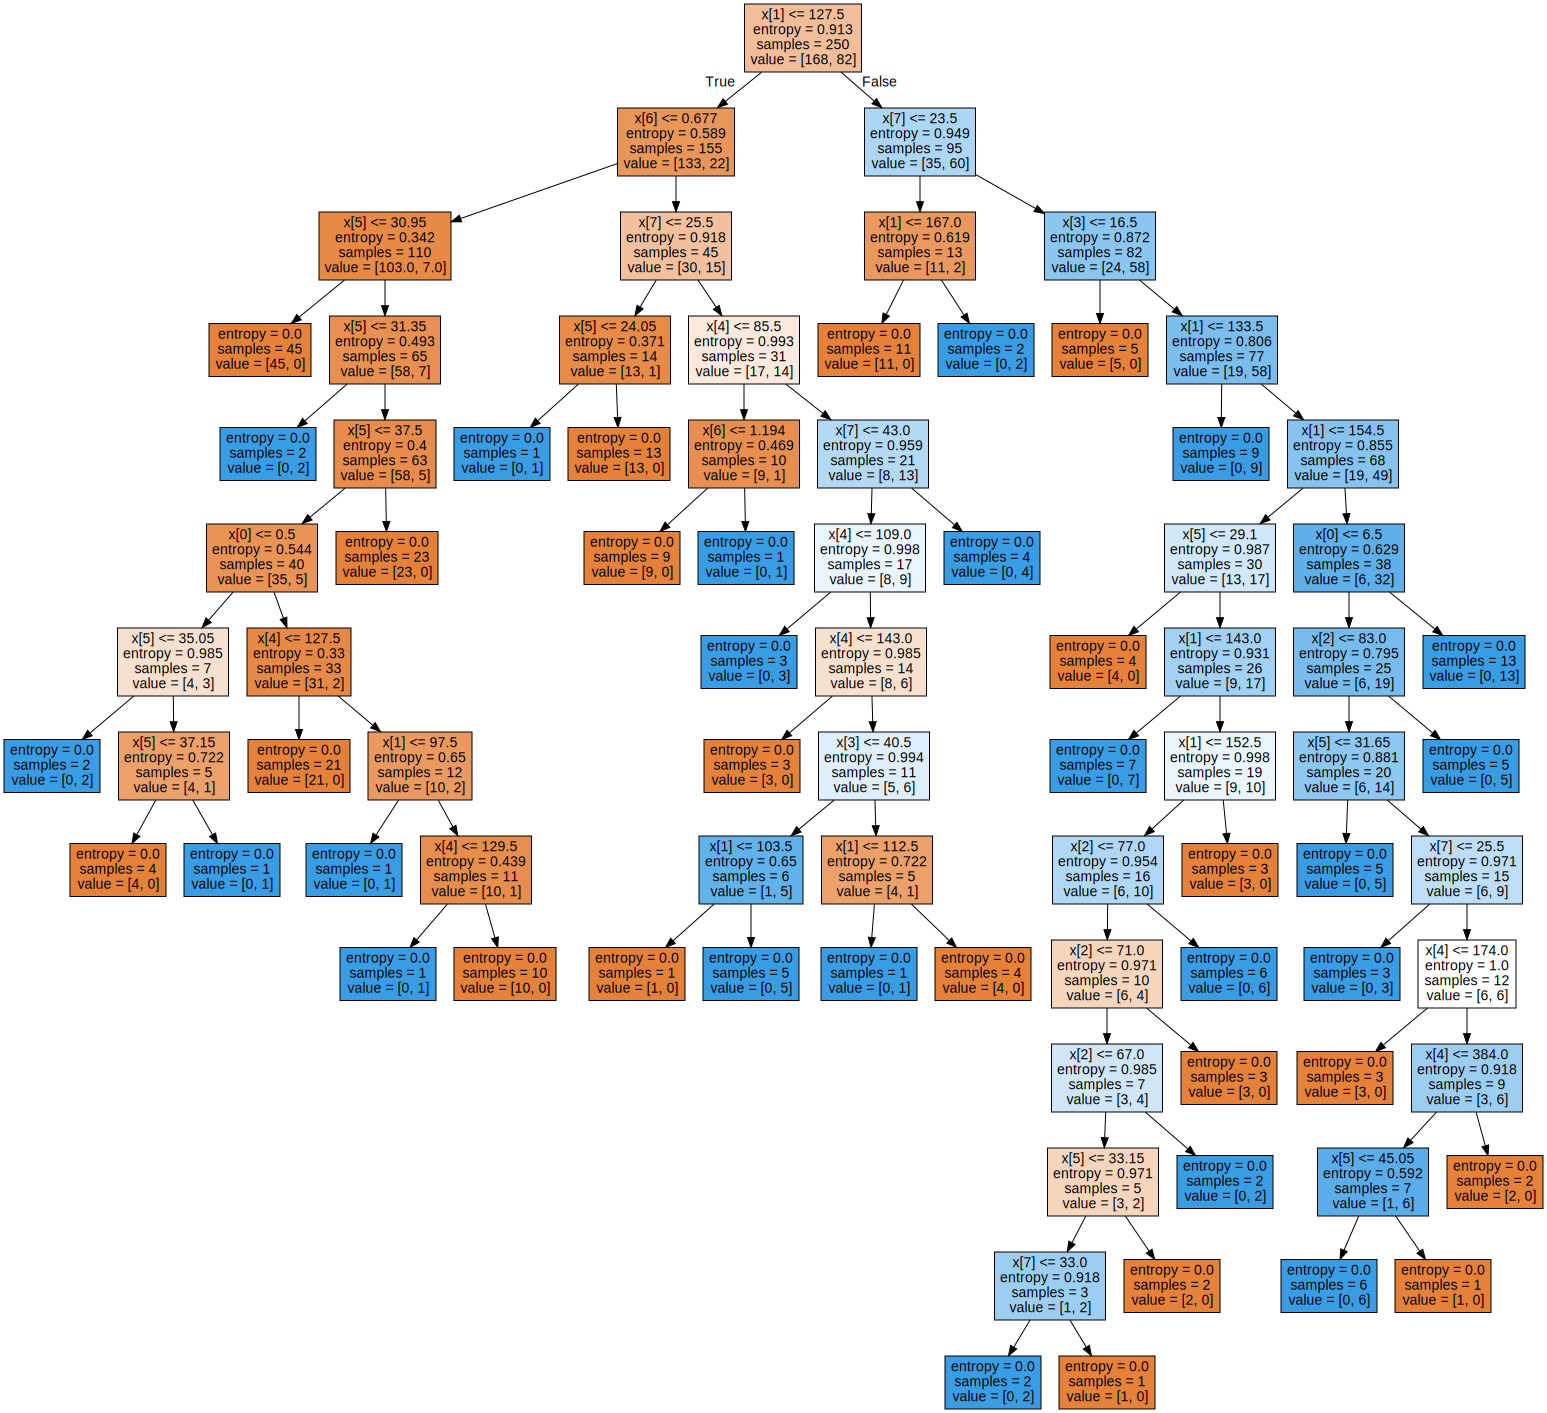

In [38]:
dot_data = tree.export_graphviz(decision_tree_q3, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [62]:
# Creating a model w sklearn's RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators=100)

# Training/fitting the model with training data
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10000)

Print accuracy of training and validation data.

In [63]:
# Printing accuracy of testing & training data
y_train_pred=random_forest.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=random_forest.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  82.53968253968253


How did the accuracy compare to the decision tree's accuracy?

(The accuracy of the random forest is comparable to a decision tree with a high max depth, as it had a high training accuracy but had a drop-off in validation accuracy)

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [42]:
print(decision_tree_q3.feature_importances_)

#1: Plasma Glucose Level
#2: BMI
#3: Insulin

[0.03503905 0.36226671 0.05550136 0.05640576 0.12167325 0.18693498
 0.0750045  0.1071744 ]


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

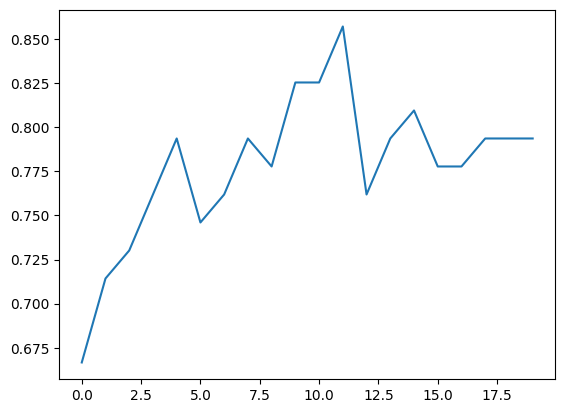

In [43]:
accuracyList = []

for i in range(1,100,5):
  random_forest = RandomForestClassifier(n_estimators=i)
  random_forest.fit(X_train,y_train)
  y_val_pred = random_forest.predict(X_val)
  accuracy = accuracy_score(y_val, y_val_pred)
  accuracyList.append(accuracy)


plt.plot(accuracyList)

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

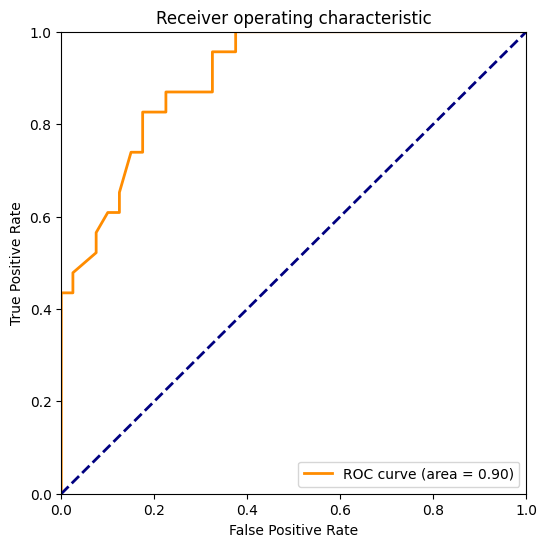

In [46]:
y_val_prob = random_forest.predict_proba(X_val)[:,1]

fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob)

roc_auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(6,6))
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()